# ACCIDENT SEVERITY PREDICTION

____________________________________________________________________________________________________

GOAL: Build a machine learning model to predict accident severity (Fatal vs. Injured).


DELIVERABLES: Trained Model, Performance Analysis (ROC-AUC), Actionable Insights.

In [14]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    roc_auc_score, accuracy_score
)

sns.set(style="whitegrid")
%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [15]:
# Load the dataset
# low_memory=False is used to handle mixed data types in large files
try:
    df = pd.read_csv('Vehicle Collision.csv', low_memory=False)
    print(f"✓ Dataset loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Please ensure 'Vehicle Collision.csv' is in the directory.")

✓ Dataset loaded. Shape: (230660, 21)


In [16]:
# 1. DEFINING TARGET VARIABLE
# The project requires predicting 'Fatal' (Killed) vs 'Injured'.
# We filter the dataset to only include rows where PERSON_INJURY is known.

df_clean = df.copy()

# Remove rows where injury status is missing or ambiguous
df_clean = df_clean.dropna(subset=['PERSON_INJURY'])
df_clean = df_clean[df_clean['PERSON_INJURY'].isin(['Killed', 'Injured'])]

# Map Target: 1 = Killed (Severe), 0 = Injured (Non-Severe)
df_clean['Target'] = df_clean['PERSON_INJURY'].apply(lambda x: 1 if x == 'Killed' else 0)

print("Target Distribution:")
print(df_clean['Target'].value_counts(normalize=True))






Target Distribution:
Target
0    0.995565
1    0.004435
Name: proportion, dtype: float64


In [17]:
# 2. FEATURE SELECTION
# Selecting features that might influence accident severity based on domain knowledge
feature_cols = [
    'PERSON_AGE', 'PERSON_SEX', 'PERSON_TYPE', 
    'EJECTION', 'EMOTIONAL_STATUS', 'SAFETY_EQUIPMENT',
    'POSITION_IN_VEHICLE', 'CONTRIBUTING_FACTOR_1'
]


In [18]:
# 3. HANDLING MISSING VALUES
# Impute Age with Median
imputer_age = SimpleImputer(strategy='median')
df_clean['PERSON_AGE'] = imputer_age.fit_transform(df_clean[['PERSON_AGE']])

In [19]:
# Filling categorical missing values with 'Unknown'
for col in feature_cols:
    if col != 'PERSON_AGE':
        df_clean[col] = df_clean[col].fillna('Unknown')

print("✓ Preprocessing complete")

✓ Preprocessing complete


In [20]:
# Encoding Categorical Variables
# We use Label Encoding to convert text to numbers for the Random Forest model.

X = df_clean[feature_cols].copy()
y = df_clean['Target']
encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = X[col].astype(str) # Ensure all data is string before encoding
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("✓ Feature engineering complete")
X.head()

✓ Feature engineering complete


,PERSON_AGE,PERSON_SEX,PERSON_TYPE,EJECTION,EMOTIONAL_STATUS,SAFETY_EQUIPMENT,POSITION_IN_VEHICLE,CONTRIBUTING_FACTOR_1
0,27.0,1,1,2,1,11,2,45
1,24.0,0,3,5,1,15,10,48
2,42.0,1,0,2,7,15,2,45
3,36.0,1,0,2,1,15,2,45
4,50.0,0,1,2,1,11,3,45


In [21]:
# Encoding Categorical Variables
# We use Label Encoding to convert text to numbers for the Random Forest model.

X = df_clean[feature_cols].copy()
y = df_clean['Target']
encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = X[col].astype(str) # Ensure all data is string before encoding
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print("✓ Feature engineering complete")
X.head()

✓ Feature engineering complete


,PERSON_AGE,PERSON_SEX,PERSON_TYPE,EJECTION,EMOTIONAL_STATUS,SAFETY_EQUIPMENT,POSITION_IN_VEHICLE,CONTRIBUTING_FACTOR_1
0,27.0,1,1,2,1,11,2,45
1,24.0,0,3,5,1,15,10,48
2,42.0,1,0,2,7,15,2,45
3,36.0,1,0,2,1,15,2,45
4,50.0,0,1,2,1,11,3,45


Train-Test split

In [22]:
# Spliting Data (80% Train, 20% Test)
# Stratify is important here to maintain the ratio of Fatal/Injured in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Random Forest Classifier
# class_weight='balanced' is CRITICAL to handle the imbalance (fewer deaths than injuries)
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)

# Train the model
print("Training model... this may take a moment.")
model.fit(X_train_scaled, y_train)
print("✓ Model training complete")

Training model... this may take a moment.
✓ Model training complete


Model Evaluation

In [23]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\n" + "="*40)
print("MODEL EVALUATION")
print("="*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


MODEL EVALUATION
Accuracy:  0.8951
ROC AUC:   0.8073

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.94     45927
           1       0.02      0.56      0.04       205

    accuracy                           0.90     46132
   macro avg       0.51      0.73      0.49     46132
weighted avg       0.99      0.90      0.94     46132


Confusion Matrix:
[[41179  4748]
 [   91   114]]



CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.90      0.94     45927
           1       0.02      0.56      0.04       205

    accuracy                           0.90     46132
   macro avg       0.51      0.73      0.49     46132
weighted avg       0.99      0.90      0.94     46132



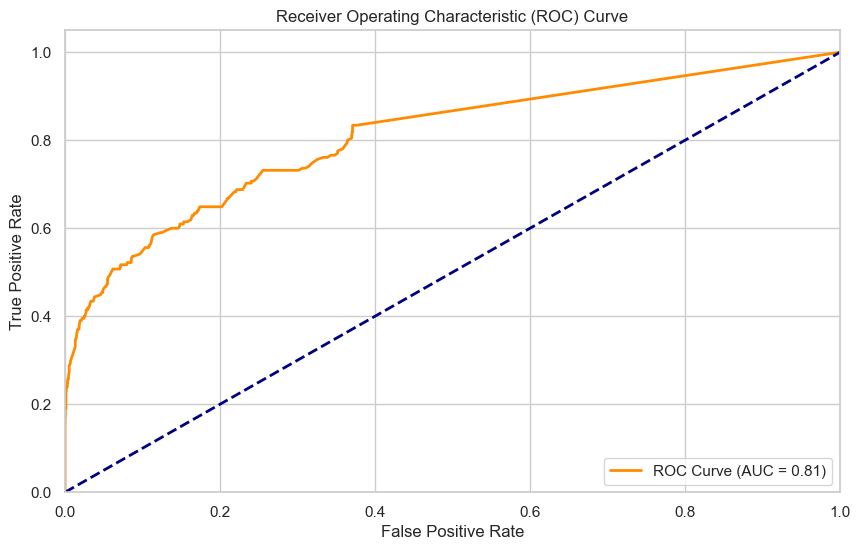

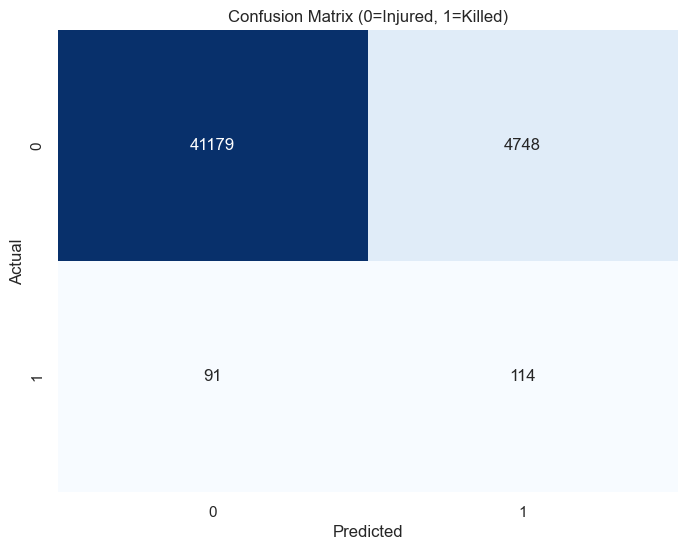

In [24]:
# Generate Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 1. Classification Report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# 2. ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 3. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (0=Injured, 1=Killed)')
plt.show()


KEY FACTORS INFLUENCING SEVERITY:
1. EMOTIONAL_STATUS (0.3505)
2. PERSON_AGE (0.3167)
3. PERSON_TYPE (0.1287)
4. EJECTION (0.0652)
5. SAFETY_EQUIPMENT (0.0590)
6. CONTRIBUTING_FACTOR_1 (0.0277)
7. POSITION_IN_VEHICLE (0.0277)
8. PERSON_SEX (0.0245)


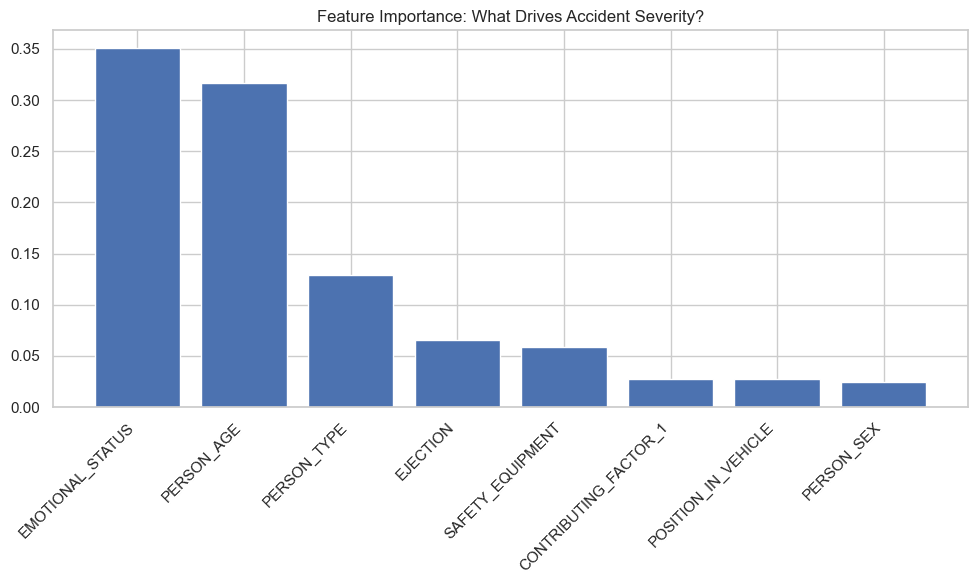

In [25]:
# Extract Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print Top Factors
print("\nKEY FACTORS INFLUENCING SEVERITY:")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_cols[indices[f]]} ({importances[indices[f]]:.4f})")

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance: What Drives Accident Severity?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# Save the trained model and artifacts for submission
artifacts = {
    'features': feature_cols,
    'model_params': model.get_params()
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(model, f)
    
print("✓ Model saved as 'model_artifacts.pkl'")

✓ Model saved as 'model_artifacts.pkl'
